In [1]:
# importing all the required dependencies
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv("../data/WA_Fn-UseC_-Telco-Customer-Churn.csv")               
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
print(f"The dataset has {df.shape[0]} rows and {df.shape[1]} columns")

The dataset has 7043 rows and 21 columns


In [4]:
print(df.isnull().sum())

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [5]:
df.duplicated().sum()

np.int64(0)

- The dataset contains no null values and no duplicate records.

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [7]:
df['TotalCharges'] = df['TotalCharges'].replace(' ', 0)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'])

In [8]:
df.drop(columns=['customerID'], inplace=True)

- TotalCharges had some empty values, so replace them with 0 and convert it into a numeric.
- Dropped 'customerID' column as it did not provide any information about the target variable.

In [9]:
print(df.describe())

       SeniorCitizen       tenure  MonthlyCharges  TotalCharges
count    7043.000000  7043.000000     7043.000000   7043.000000
mean        0.162147    32.371149       64.761692   2279.734304
std         0.368612    24.559481       30.090047   2266.794470
min         0.000000     0.000000       18.250000      0.000000
25%         0.000000     9.000000       35.500000    398.550000
50%         0.000000    29.000000       70.350000   1394.550000
75%         0.000000    55.000000       89.850000   3786.600000
max         1.000000    72.000000      118.750000   8684.800000


In [10]:
print("Unique Values")
for col in df.columns:
  if df[col].dtypes == 'object':
    print(f"{col} --- {df[col].unique()}")

Unique Values
gender --- ['Female' 'Male']
Partner --- ['Yes' 'No']
Dependents --- ['No' 'Yes']
PhoneService --- ['No' 'Yes']
MultipleLines --- ['No phone service' 'No' 'Yes']
InternetService --- ['DSL' 'Fiber optic' 'No']
OnlineSecurity --- ['No' 'Yes' 'No internet service']
OnlineBackup --- ['Yes' 'No' 'No internet service']
DeviceProtection --- ['No' 'Yes' 'No internet service']
TechSupport --- ['No' 'Yes' 'No internet service']
StreamingTV --- ['No' 'Yes' 'No internet service']
StreamingMovies --- ['No' 'Yes' 'No internet service']
Contract --- ['Month-to-month' 'One year' 'Two year']
PaperlessBilling --- ['Yes' 'No']
PaymentMethod --- ['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']
Churn --- ['No' 'Yes']


In [11]:
df['MultipleLines'] = df['MultipleLines'].replace('No phone service', 'No')
df['OnlineSecurity'] = df['OnlineSecurity'].replace('No internet service', 'No')
df['OnlineBackup'] = df['OnlineBackup'].replace('No internet service', 'No')
df['DeviceProtection'] = df['DeviceProtection'].replace('No internet service', 'No')
df['TechSupport'] = df['TechSupport'].replace('No internet service', 'No')
df['StreamingTV'] = df['StreamingTV'].replace('No internet service', 'No')
df['StreamingMovies'] = df['StreamingMovies'].replace('No internet service', 'No')
df['PaymentMethod'] = df['PaymentMethod'].replace({'Bank transfer (automatic)':'Bank transfer','Credit card (automatic)':'Credit card'})

In [12]:
print("Unique Values")
for col in df.columns:
  if df[col].dtypes == 'object':
    print(f"{col} --- {df[col].unique()}")

Unique Values
gender --- ['Female' 'Male']
Partner --- ['Yes' 'No']
Dependents --- ['No' 'Yes']
PhoneService --- ['No' 'Yes']
MultipleLines --- ['No' 'Yes']
InternetService --- ['DSL' 'Fiber optic' 'No']
OnlineSecurity --- ['No' 'Yes']
OnlineBackup --- ['Yes' 'No']
DeviceProtection --- ['No' 'Yes']
TechSupport --- ['No' 'Yes']
StreamingTV --- ['No' 'Yes']
StreamingMovies --- ['No' 'Yes']
Contract --- ['Month-to-month' 'One year' 'Two year']
PaperlessBilling --- ['Yes' 'No']
PaymentMethod --- ['Electronic check' 'Mailed check' 'Bank transfer' 'Credit card']
Churn --- ['No' 'Yes']


In [13]:
# creating a new column for total services
services = ['PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies']
services_count = (df[services] == 'Yes').sum(axis=1)
int_service = (df['InternetService'] != 'No').astype(int)
df['TotalServices'] = services_count + int_service

- Saved the currently cleaned data for visualization purposes.

In [14]:
df.to_csv('../data/vis_data.csv', index=False)

# EDA

In [15]:
# separate the numerical and categorical columns
services_col = ['PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies']
customers_info = ['gender', 'SeniorCitizen', 'Partner', 'Dependents']
payment_col = ['Contract', 'PaperlessBilling', 'PaymentMethod']

num_cols = df.drop(columns='SeniorCitizen').select_dtypes(['int','float']).columns

In [16]:
colors= sns.color_palette("Set2")

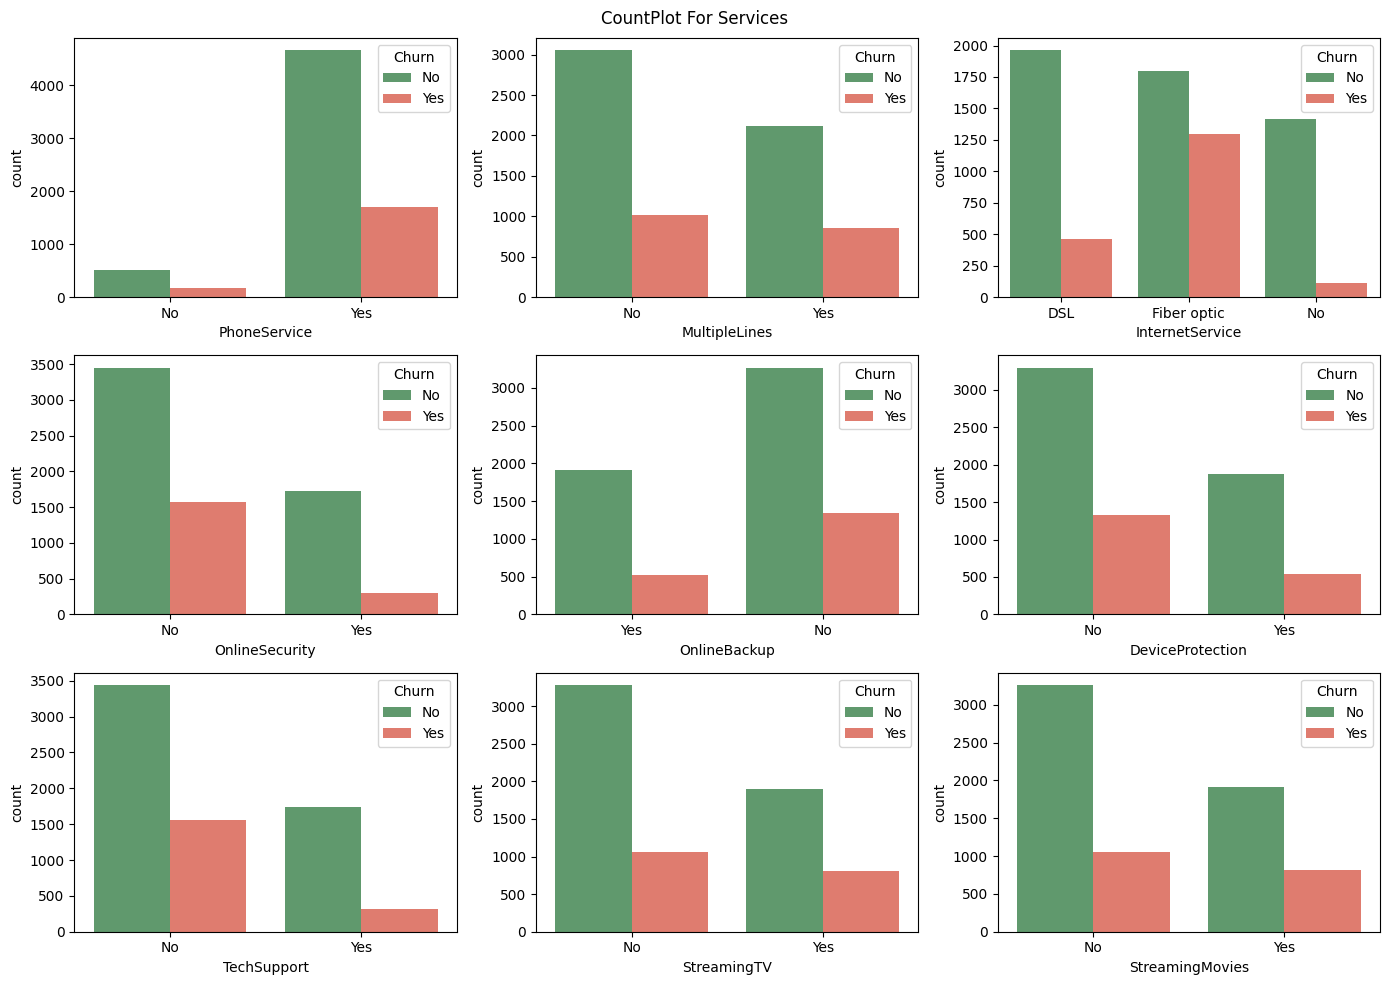

In [17]:
# let's see the distribution of categories across all service features for each class
n_rows = 3
n_cols = 3
colors= ["#56a368", "#f26e5c"]
fig, axes = plt.subplots(n_rows, n_cols, figsize=(14,10))
axes = axes.flatten() # for easy iteration
for i, col in enumerate(services_col):
  sns.countplot(x=df[col], ax=axes[i], palette=colors, hue=df['Churn'])

plt.suptitle("CountPlot For Services")
plt.tight_layout() # adjust the subplots
plt.show()

- Customers who don't subscribe to 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', or 'MultilinesService' appear to have a higher churn rate.
- Consumers with FiberOptic Internet Service are churning more, followed by DSL customers, suggesting an improvement in both segments.
- Customers who subscribe to 'PhoneService', appear to have a high churn rate, indicating there may be issues with the service.

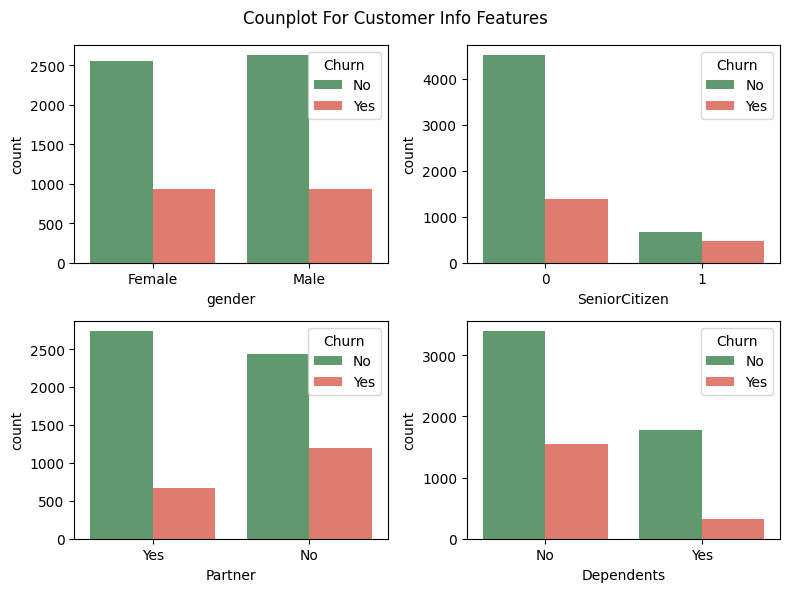

In [18]:
# let's see the countplot for customers' info features
fig, axes = plt.subplots(nrows=2, ncols = 2, figsize=(8,6))
colors= ["#56a368", "#f26e5c"]
index=0

for i in range(2):
    for j in range(2):
        current_col = customers_info[index]
        sns.countplot(data=df, x=current_col, ax=axes[i, j], palette=colors, hue=df['Churn'])
        index += 1

plt.suptitle("Counplot For Customer Info Features")
plt.tight_layout()
plt.show()

- The customer's gender does not affect the churn rate.
- Customers who are young, unmarried, and have no dependents appear to have a higher churn rate. 

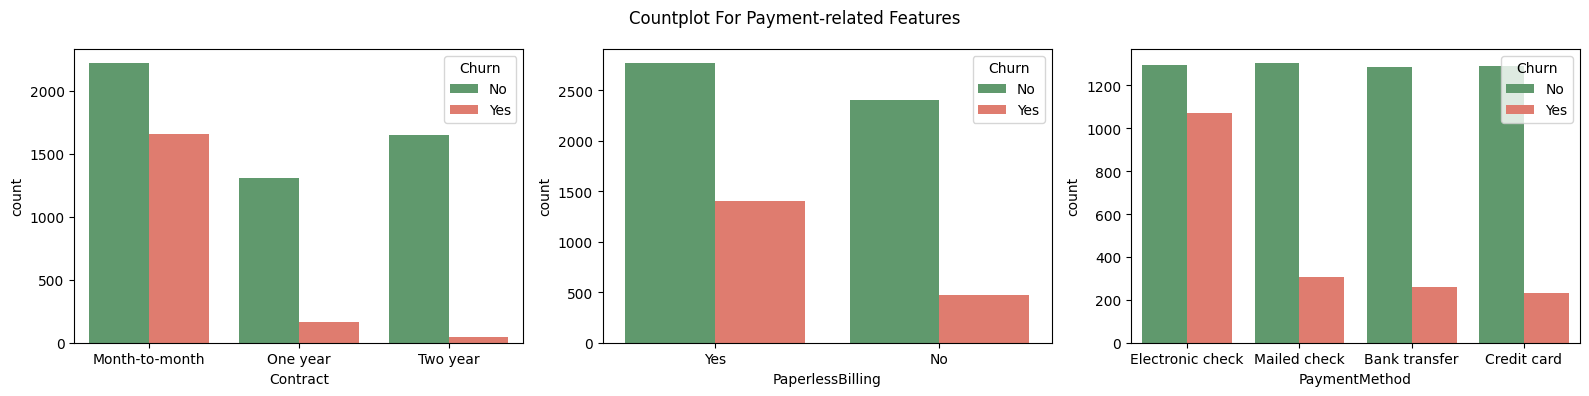

In [19]:
# let's see the countplot for payment-related features
fig, axes = plt.subplots(1,3, figsize=(16,4))
colors= ["#56a368", "#f26e5c"]
axes = axes.flatten()
for i, col in enumerate(payment_col):
    sns.countplot(data = df, x=col, ax= axes[i], hue=df['Churn'], palette=colors)

plt.suptitle("Countplot For Payment-related Features")
plt.tight_layout()
plt.show()

- Customers on month-to-month contracts tend to churn more than those on longer-term contracts.
- Customers enrolled in paperless billing have a higher churn rate, suggesting issues with the paperless billing experience.
- Customers who pay by electronic check have a higher churn rate than those using other payment methods.

- Separating the dataset into churn and non-churn segments to extract clearer visual insights.

In [20]:
churn_df = df[df['Churn'] == 'Yes']
nochurn_df = df[df['Churn'] == 'No']

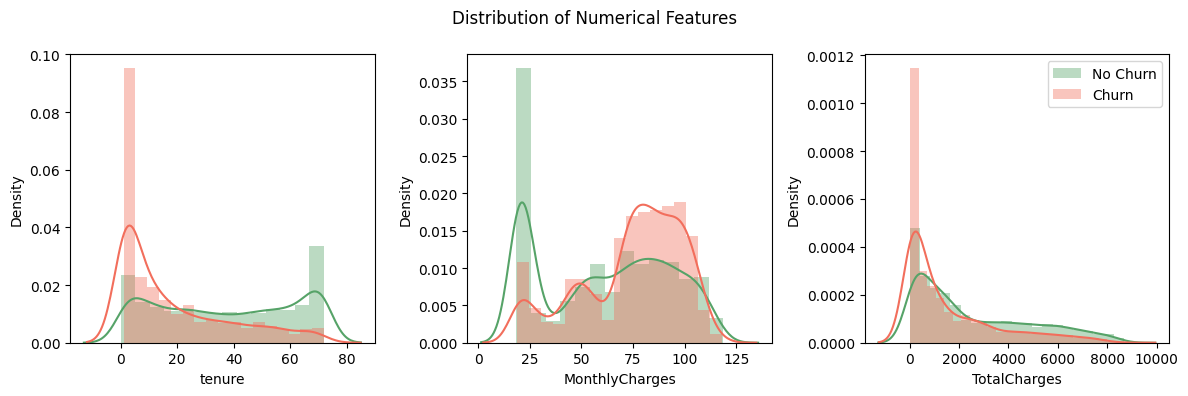

In [21]:
# let's see the distribution of numerical features
num_col = num_cols.drop('TotalServices')
fig, axes= plt.subplots(1,3,figsize=(12,4))
axes= axes.flatten()
for i, col in enumerate(num_col):
    sns.distplot(nochurn_df[col], ax=axes[i], color='#56a368', kde=True, label='No Churn')
    sns.distplot(churn_df[col], ax=axes[i], color='#f26e5c', kde=True, label='Churn')
  

plt.suptitle("Distribution of Numerical Features")
plt.legend()
plt.tight_layout()
plt.show()

- Customers with shorter tenure appear to churn more often than those with longer tenure.
- Customers with higher monthly charges tend to churn more than those with lower monthly charges.
- None of the numerical features are normally distributed. 'TotalCharges' is highly right-skewed.

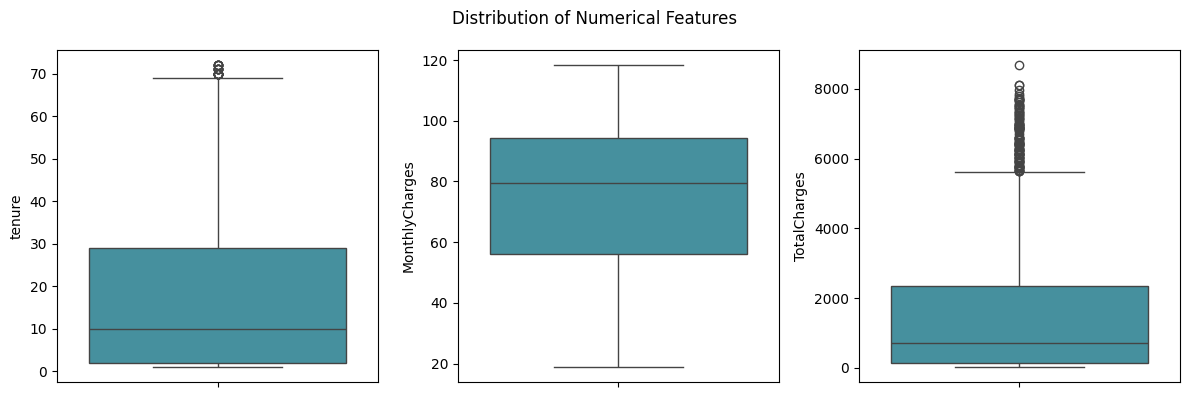

In [22]:
# let's see the distribution of numerical features using Boxplot
num_col = num_cols.drop('TotalServices')

fig, axes= plt.subplots(1,3,figsize=(12,4))
axes= axes.flatten()
for i, col in enumerate(num_col):
    sns.boxplot(churn_df[col], ax=axes[i], color='#379aad')

plt.suptitle("Distribution of Numerical Features")
plt.tight_layout()
plt.show()

- There are a few high-value outliers in tenure.
- Total Charges also contains many high-value outliers.

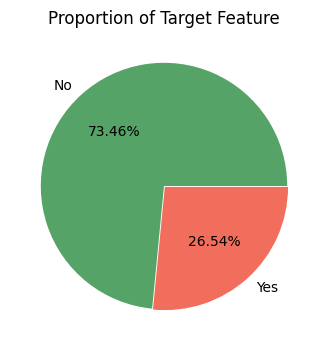

In [23]:
# let's see the distribution of the target
plt.figure(figsize=(5,4))
labels =df['Churn'].value_counts().index
plt.pie(df['Churn'].value_counts(), labels= labels, autopct='%.2f%%', explode= (0,0.01), colors= ["#56a368", "#f26e5c"])
plt.title("Proportion of Target Feature")
plt.show()

- This dataset shows that 73.46% of customers are not expected to churn, while 26.54% are expected to churn. That shows class imbalance.

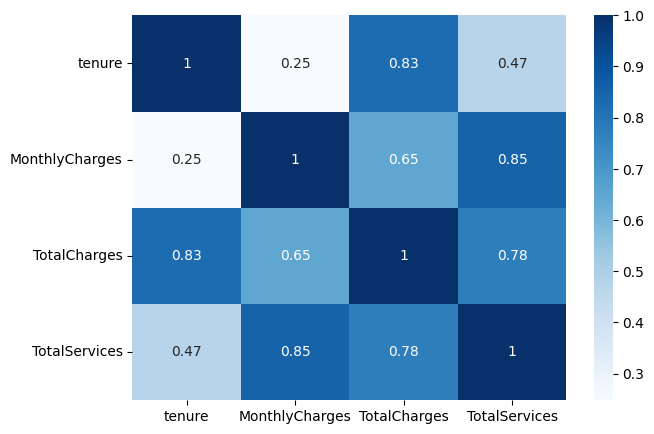

In [24]:
# let's see correlation between numerical features
corr = df[num_cols].corr()
plt.figure(figsize=(7,5))
sns.heatmap(corr, annot=True,cmap='Blues')
plt.show()

- 'TotalCharges' and 'tenure' are strongly positively correlated with each other. However, removing the 'TotalCharges' column.
- 'TotalServices' is strongly positively correlated with 'MonthlyCharges. However, removing the 'TotalServices' column.

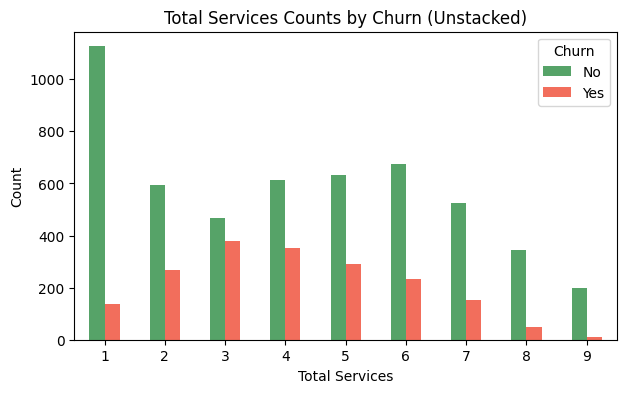

In [25]:
# let's see how the values of TotalServices are distributed between churn and non-churn segments
grouped_counts = df.groupby(['Churn', 'TotalServices']).size().unstack(level='Churn')

# plot the unstacked DataFrame as a bar chart
grouped_counts.plot(kind='bar', stacked=False, figsize=(7, 4), color=["#56a368", "#f26e5c"])
plt.title('Total Services Counts by Churn (Unstacked)')
plt.xlabel('Total Services')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

- Customers with only three services have a high churn rate, followed by those with four services. 

In [26]:
df.drop(columns=['TotalCharges', 'TotalServices'], inplace=True)

In [27]:
df.duplicated().sum()

np.int64(27)

Some duplicate data points appeared in the dataset after feature engineering, so we are dropping them.

In [28]:
df.drop_duplicates(inplace=True)

- After removing the correlated features, I saved the data for model training.After romovin

In [29]:
#  save the file as 'ml_data.csv' file for model training
df.to_csv('../data/ml_data.csv', index=False)